In [1]:
import numpy as np
import socket
import cv2
import matplotlib.pyplot as plt
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TORCH_BLAS_PREFER_HIPBLASLT'] = '0'

## Run the Java Tetris Server using subprocess

In [2]:
import subprocess
subprocess.Popen(["/usr/bin/java","-jar","/home/rvl/mingwei/NTUT_Deep_Learning/hw4/TetrisTCPserver_v0.6.jar"])

<Popen: returncode: None args: ['/usr/bin/java', '-jar', '/home/rvl/mingwei/...>

Tetris TCP server is listening at 10612


## Create our own Tetris Test environment by inheriting Gym class

In [3]:
import gymnasium as gym
from gymnasium import spaces

In [4]:
class TetrisEnv(gym.Env):

    metadata = {"render_modes": ["human"], "render_fps": 20}

    '''
        The supported actions are
        0: move -1
        1: move 1
        2: rotate 0 // counter-clockwise
        3: rotate 1 // clockwise
        4: drop down
    '''
    N_DISCRETE_ACTIONS = 5

    IMG_HEIGHT = 200
    IMG_WIDTH = 100
    IMG_CHANNELS = 3


    def __init__(self, host_ip="127.0.0.1", host_port=10612):
        super().__init__()

        self.action_space = spaces.Discrete(self.N_DISCRETE_ACTIONS)
        # Example for using image as input (channel-first; channel-last also works):
        self.observation_space = spaces.Box(low=0, high=255,
                                            shape=(self.IMG_HEIGHT, self.IMG_WIDTH, self.IMG_CHANNELS), dtype=np.uint8)
        self.server_ip = host_ip
        self.server_port = host_port

        self.client_sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        self.client_sock.connect((self.server_ip, self.server_port))

    # def step(self, action):
    #     if action == 0:
    #         self.client_sock.sendall(b"move -1\n")
    #     elif action == 1:
    #         self.client_sock.sendall(b"move 1\n")
    #     elif action == 2:
    #         self.client_sock.sendall(b"rotate 0\n")
    #     elif action == 3:
    #         self.client_sock.sendall(b"rotate 1\n")
    #     elif action == 4:
    #         self.client_sock.sendall(b"drop\n")

    #     terminated, lines, height, holes, observation = self.get_tetris_server_response(self.client_sock)
    #     self.observation = observation

    #     reward = 0
    #     if action == 4: # Drop reward
    #         reward += 5

    #     # Negative height reward
    #     if height > self.height:
    #         reward -= (height - self.height)*5

    #     # Positive hole reduction reward
    #     if holes < self.holes:
    #         reward += (self.holes - holes)*10

    #     if lines > self.lines_removed:
    #         reward += 100*(2**(lines - self.lines_removed)-1)
    #         self.lines_removed = lines

    
        
    #     self.holes = holes
    #     self.height = height
    #     self.lifetime += 1
    #     truncated = False
    #     info = {'removed_lines':self.lines_removed, 'lifetime':self.lifetime}
    #     return (observation, reward, terminated, truncated, info)
    def step(self, action):
        # ... (動作發送) ...
        if action == 0: self.client_sock.sendall(b"move -1\n")
        elif action == 1: self.client_sock.sendall(b"move 1\n")
        elif action == 2: self.client_sock.sendall(b"rotate 0\n")
        elif action == 3: self.client_sock.sendall(b"rotate 1\n")
        elif action == 4: self.client_sock.sendall(b"drop\n")

        terminated, server_lines, server_height, server_holes, observation = self.get_tetris_server_response(self.client_sock)
        self.observation = observation

        reward = 0.0 # 使用浮點數

        # --- 獎勵計算 ---

        # 1. 對當前洞數的直接懲罰
        reward -= server_holes * 2.0  # 每個洞懲罰 -2.0

        # 2. 洞數變化的獎勵/懲罰
        if server_holes < self.holes: # 填補了洞
            reward += (self.holes - server_holes) * 10.0 # 每個被填補的洞獎勵 +10
        elif server_holes > self.holes and not terminated: # 產生了新的洞
            reward -= (server_holes - self.holes) * 5.0  # 每個新增的洞懲罰 -5 (比填補的獎勵小)

        # 3. 高度變化的懲罰/獎勵
        if server_height > self.height: # 高度增加了
            reward -= (server_height - self.height) * 5.0 # 高度增加懲罰
        elif server_height < self.height: # 高度降低了 (通常因為消行)
            reward += (self.height - server_height) * 2.0 # 獎勵高度降低

        # 4. 消除行獎勵 (指數級增長)
        if server_lines > self.lines_removed:
            lines_cleared_this_step = server_lines - self.lines_removed
            reward += 100 * ( (2**lines_cleared_this_step) - 1 )
        # self.lines_removed 的更新在下面

        # 5. Drop動作小獎勵
        if action == 4:
            reward += 5.0

        # 6. 生存獎勵
        if not terminated:
            reward += 0.5 # 略微提高生存獎勵，但仍需遠小於其他主要獎懲

        # 7. 遊戲結束的巨大懲罰
        if terminated:
            reward -= 1000.0 # 顯著的負獎勵

        # --- 獎勵計算結束 ---

        # 更新用於下一次比較的狀態
        self.lines_removed = server_lines
        self.holes = server_holes
        self.height = server_height
        self.lifetime += 1
        truncated = False
        # 確保 info 字典中包含 is_success，EvalCallback 可能會用到
        info = {'removed_lines': self.lines_removed, 'lifetime': self.lifetime, 'is_success': terminated}
        return (self.observation, reward, terminated, truncated, info)



    def reset(self, seed=None, options=None):
        self.client_sock.sendall(b"start\n")
        terminated, lines, height, holes, observation = self.get_tetris_server_response(self.client_sock)

        if observation is None:
            observation = np.zeros((self.IMG_HEIGHT, self.IMG_WIDTH, self.IMG_CHANNELS), dtype=np.uint8)
            
        self.observation = observation
        self.reward = 0
        self.lines_removed = 0
        self.holes = 0
        self.height = 0
        self.lifetime = 0
        info = {}
        return observation, info

    def render(self):
        ''''''
        #if self.render_mode == "console":
        #    print('Total reward ' + str(self.reward))
        '''
        if self.render_mode == "human":
            cv2.imshow("Image", self.observation)
            cv2.waitKey(0)
            cv2.destroyAllWindows()
        '''

    def close(self):
        self.client_sock.close()

    def get_tetris_server_response(self, sock):
        is_game_over = (sock.recv(1) == b'\x01')
        removed_lines = int.from_bytes(sock.recv(4), 'big')
        height = int.from_bytes(sock.recv(4), 'big')
        holes = int.from_bytes(sock.recv(4), 'big')
        img_size = int.from_bytes(sock.recv(4), 'big')
        img_png = sock.recv(img_size)
        
        nparr = np.frombuffer(img_png, np.uint8)
        np_image = cv2.imdecode(nparr, -1)

        if np_image is None:
            np_image = np.zeros((self.IMG_HEIGHT, self.IMG_WIDTH, self.IMG_CHANNELS), dtype=np.uint8)

        return is_game_over, removed_lines, height, holes, np_image

## Use SB3 env_checker to check our environment

In [5]:
from stable_baselines3.common.env_checker import check_env

env = TetrisEnv()
# It will check your custom environment and output additional warnings if needed
# No response may be caused by mismatched action state definition and implementation
check_env(env)

Client has joined the game


## Randomly test the environment

In [6]:
obs, info = env.reset()
n_steps = 20
for _ in range(n_steps):
    # Random action
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    
    env.render() # We render nothing now
    
    if terminated:
        break

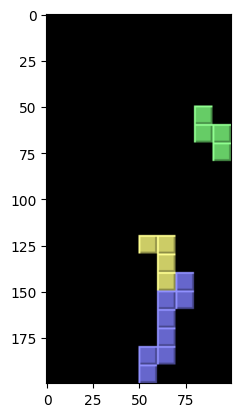

In [7]:
# Show the final screen
%matplotlib inline 
plt.imshow(obs)

## Create an environment with 30 client threads

In [8]:
from stable_baselines3 import PPO, A2C, DQN, DDPG
from stable_baselines3.common.env_util import make_vec_env

In [9]:
# Let's try A2C by creating 30 environments
num_envs = 50
vec_env = make_vec_env(TetrisEnv, n_envs= num_envs)

Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
C

## We choose A2C with CNN policy, and train 1,000,000 steps

In [10]:
import torch

if torch.cuda.is_available():
    print(f"使用GPU: {torch.cuda.get_device_name(0)}")
    device = "cuda"
else:
    print("沒有可用的GPU，將使用CPU")
    device = "cpu"


os.makedirs("./sb3_log/", exist_ok=True)

# # --- A2C 超參數配置 ---
# a2c_params = {
#     'policy': "CnnPolicy",
#     'env': vec_env,
#     'learning_rate': 2e-4,       # 學習率
#     'n_steps': 5,                # 每個環境收集的步數，A2C通常較小
#     'gamma': 0.99,               # 折扣因子
#     'gae_lambda': 1.0,           # GAE lambda，A2C通常設為1.0 (等價於高方差的蒙特卡洛方法)
#     'ent_coef': 0.01,            # 熵係數 (鼓勵探索)
#     'vf_coef': 0.25,             # 價值函數損失的係數
#     'max_grad_norm': 0.5,        # 梯度裁剪
#     'rms_prop_eps': 1e-5,        # RMSprop優化器的epsilon
#     'use_rms_prop': True,        # A2C通常使用RMSprop
#     'use_sde': False,            # 不使用狀態相關探索
#     'normalize_advantage': False, # 不標準化優勢函數 (A2C預設為False)
#     'verbose': 1,
#     'device': device,
#     'tensorboard_log': "./sb3_log/"
# }


# # 創建 A2C 模型
# model = A2C(**a2c_params)
print("A2C 模型初始化完成！")


使用GPU: Radeon RX 7900 XTX
A2C 模型初始化完成！


## Training with 1000000 steps


In [12]:
from stable_baselines3.common.callbacks import CheckpointCallback

# 設定儲存模型的資料夾
checkpoint_dir = './checkpoints/'
os.makedirs(checkpoint_dir, exist_ok=True)

# 每隔 100_000 步存一次模型（依據 n_envs 調整頻率，這裡假設 n_envs=24）
save_freq = max(2_000_000 // num_envs, 1)

# 建立 CheckpointCallback
checkpoint_callback = CheckpointCallback(
    save_freq=save_freq,
    save_path=checkpoint_dir,
    name_prefix='a2c_tetris',
    verbose=2  # 會在儲存時顯示訊息
)

In [ ]:
import time

model = A2C("CnnPolicy", vec_env, verbose=1, tensorboard_log="./sb3_log/", learning_rate=5e-5)
print("開始訓練A2C模型...")
start_time = time.time()

# 訓練時加入 callback
model.learn(
    total_timesteps=20_000_000,
    log_interval=2000,
    progress_bar=True,
    callback=checkpoint_callback
)

print("訓練完成！")
model.save("a2c_tetris_final")
print("模型已保存")

end_time = time.time()
training_duration = end_time - start_time
print(f"訓練總耗時: {training_duration:.2f} 秒 ({training_duration/3600:.2f} 小時)")


Using cuda device
Wrapping the env in a VecTransposeImage.
開始訓練A2C模型...
Logging to ./sb3_log/A2C_1


Output()

-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 94.6      |
|    ep_rew_mean        | -2.47e+03 |
|    success_rate       | 1         |
| time/                 |           |
|    fps                | 555       |
|    iterations         | 2000      |
|    time_elapsed       | 900       |
|    total_timesteps    | 500000    |
| train/                |           |
|    entropy_loss       | -1.19e-09 |
|    explained_variance | 0.839     |
|    learning_rate      | 5e-05     |
|    n_updates          | 1999      |
|    policy_loss        | -0        |
|    value_loss         | 5.42e+03  |
-------------------------------------


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 93.5      |
|    ep_rew_mean        | -2.51e+03 |
|    success_rate       | 1         |
| time/                 |           |
|    fps                | 552       |
|    iterations         | 4000      |
|    time_elapsed       | 1810      |
|    total_timesteps    | 1000000   |
| train/                |           |
|    entropy_loss       | -6.15e-10 |
|    explained_variance | 0.916     |
|    learning_rate      | 5e-05     |
|    n_updates          | 3999      |
|    policy_loss        | -0        |
|    value_loss         | 3.36e+03  |
-------------------------------------


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 93.2      |
|    ep_rew_mean        | -2.44e+03 |
|    success_rate       | 1         |
| time/                 |           |
|    fps                | 550       |
|    iterations         | 6000      |
|    time_elapsed       | 2723      |
|    total_timesteps    | 1500000   |
| train/                |           |
|    entropy_loss       | -1.03e-09 |
|    explained_variance | 0.94      |
|    learning_rate      | 5e-05     |
|    n_updates          | 5999      |
|    policy_loss        | -0        |
|    value_loss         | 1.93e+03  |
-------------------------------------


Saving model checkpoint to ./checkpoints/a2c_tetris_2000000_steps.zip

-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 94.7      |
|    ep_rew_mean        | -2.43e+03 |
|    success_rate       | 1         |
| time/                 |           |
|    fps                | 549       |
|    iterations         | 8000      |
|    time_elapsed       | 3639      |
|    total_timesteps    | 2000000   |
| train/                |           |
|    entropy_loss       | -4.52e-09 |
|    explained_variance | 0.934     |
|    learning_rate      | 5e-05     |
|    n_updates          | 7999      |
|    policy_loss        | -0        |
|    value_loss         | 2.03e+03  |
-------------------------------------


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 92.9      |
|    ep_rew_mean        | -2.44e+03 |
|    success_rate       | 1         |
| time/                 |           |
|    fps                | 548       |
|    iterations         | 10000     |
|    time_elapsed       | 4557      |
|    total_timesteps    | 2500000   |
| train/                |           |
|    entropy_loss       | -5.61e-09 |
|    explained_variance | 0.902     |
|    learning_rate      | 5e-05     |
|    n_updates          | 9999      |
|    policy_loss        | -0        |
|    value_loss         | 3.79e+03  |
-------------------------------------


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 94        |
|    ep_rew_mean        | -2.49e+03 |
|    success_rate       | 1         |
| time/                 |           |
|    fps                | 547       |
|    iterations         | 12000     |
|    time_elapsed       | 5477      |
|    total_timesteps    | 3000000   |
| train/                |           |
|    entropy_loss       | -1.37e-08 |
|    explained_variance | 0.902     |
|    learning_rate      | 5e-05     |
|    n_updates          | 11999     |
|    policy_loss        | -0        |
|    value_loss         | 3.25e+03  |
-------------------------------------


## Test our model with 1000 steps and record all plays.

In [ ]:
import os
import shutil

vec_env = make_vec_env(TetrisEnv, n_envs=num_envs)  # 或你當初用的 n_envs
model = A2C.load("/home/rvl/mingwei/NTUT_Deep_Learning/hw4/a2c_tetris_final.zip", env=vec_env)
# Test the trained agent
# using the vecenv
obs = vec_env.reset()
test_steps = 1000

replay_folder = './replay'
if os.path.exists(replay_folder):
    shutil.rmtree(replay_folder)

n_env = obs.shape[0] # Number of environments. A2C will play all envs
ep_id = np.zeros(n_env, int)
ep_steps = np.zeros(n_env, int)
cum_reward = np.zeros(n_env)
max_reward = -1e10
max_game_id = 0
max_ep_id = 0
max_rm_lines = 0
max_lifetime = 0

for step in range(test_steps):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)

    if step % 50 == 0:
        print(f"Step {step}")
        print("Action: ", action)
        print("reward=", reward, " done=", done)

    for eID in range(n_env):
        cum_reward[eID] += reward[eID]
        folder = f'{replay_folder}/{eID}/{ep_id[eID]}'
        if not os.path.exists(folder):
            os.makedirs(folder)
        fname = folder + '/' + '{:06d}'.format(ep_steps[eID]) + '.png'
        cv2.imwrite(fname, obs[eID])
        #cv2.imshow("Image" + str(eID), obs[eID])
        #cv2.waitKey(10)
        ep_steps[eID] += 1

        if done[eID]:
            if cum_reward[eID] > max_reward:
                max_reward = cum_reward[eID]
                max_game_id = eID
                max_ep_id = ep_id[eID]
                max_rm_lines = info[eID]['removed_lines']
                max_lifetime = info[eID]['lifetime']

            ep_id[eID] += 1
            cum_reward[eID] = 0
            ep_steps[eID] = 0


In [ ]:
best_replay_path = f'{replay_folder}/{max_game_id}/{max_ep_id}'


print("After playing 30 envs each for ", test_steps, " steps:")
print(" Max reward=", max_reward, " Best video: " + best_replay_path)
print(" Removed lines=", max_rm_lines, " lifetime=", max_lifetime)

## Write "removed lines" and "played steps" into a CSV file and create download link

In [ ]:
with open('tetris_best_score.csv', 'w') as fs:
    fs.write('id,removed_lines,played_steps\n')
    fs.write(f'0,{max_rm_lines}, {max_lifetime}\n')
    fs.write(f'1,{max_rm_lines}, {max_lifetime}\n')

## Make a gif image to visualize the best play

In [ ]:
import glob
import imageio

filenames = sorted(glob.glob(best_replay_path + '/*.png'))

images = []
for filename in filenames:
    images.append(imageio.imread(filename))
imageio.mimsave('replay.gif', images, loop=0)

In [ ]:
from IPython.display import Image
Image(filename='/home/rvl/mingwei/NTUT_Deep_Learning/hw4/replay.gif')

## Save your model "your_studentID_a2c_30env.zip"

In [ ]:
model.save('your_studentID_a2c_30env_1M.zip')